# Extraction & Summarisation Evaluation

1. **Entity extraction**: SpaCy baseline NER across all three source types
2. **Summarisation quality**: ROUGE scores against CNN/DailyMail gold-standard highlights
3. **Qualitative spot-checks**: best, worst, and median summaries for error analysis

In [1]:
import os
import sys

# Set working directory to project root
os.chdir('/Users/jessepassmore/Desktop/Programming_Pizazz/nlp_fun/nlp_parsing_gcp')
sys.path.insert(0, os.getcwd())

import json
import textwrap
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.data.loader import load_news, load_reviews, load_support_tickets
from src.data.preprocessing import preprocess_documents
from src.extraction.spacy_baseline import SpacyExtractor
from src.summarization.evaluation import SummarizationEvaluator

print(f'Working directory: {os.getcwd()}')
print('All imports loaded. Let\'s measure some quality!')

Working directory: /Users/jessepassmore/Desktop/Programming_Pizazz/nlp_fun/nlp_parsing_gcp
All imports loaded. Let's measure some quality!


## 1. Entity Extraction — SpaCy Baseline

SpaCy `en_core_web_sm` NER across all three source types. Establishes the baseline that GCP-native extractors are benchmarked against.

In [2]:
# Load a manageable sample from each source
reviews = load_reviews(max_docs=200)
tickets = load_support_tickets(max_docs=200)
news = load_news(max_docs=100)

# Preprocess
all_docs = reviews + tickets + news
all_docs = preprocess_documents(all_docs)

print(f'Loaded {len(reviews)} reviews, {len(tickets)} tickets, {len(news)} news articles')

/Users/jessepassmore/Desktop/Programming_Pizazz/nlp_fun/nlp_parsing_gcp/src/data/loader.py:52: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, encoding="utf-8", on_bad_lines="skip")


Loaded 200 reviews, 200 tickets, 100 news articles


In [3]:
# Fire up SpaCy
spacy_extractor = SpacyExtractor(model_name='en_core_web_sm')

# Extract entities from each source type
extraction_results = {}
for source_name, docs in [('reviews', reviews), ('tickets', tickets), ('news', news)]:
    results = spacy_extractor.extract_batch([d.text for d in docs[:100]])
    extraction_results[source_name] = results
    
    # Count entity types
    all_labels = [e.label for r in results for e in r.entities]
    label_counts = Counter(all_labels)
    total_entities = sum(len(r.entities) for r in results)
    avg_per_doc = total_entities / max(len(results), 1)
    
    print(f'\n{source_name.upper()}: {total_entities} entities ({avg_per_doc:.1f} avg/doc)')
    for label, count in label_counts.most_common(8):
        print(f'  {label:15s}: {count:4d}')


REVIEWS: 179 entities (1.8 avg/doc)
  ORG            :   73
  CARDINAL       :   46
  DATE           :   26
  PERSON         :   16
  ORDINAL        :    9
  TIME           :    4
  PRODUCT        :    2
  QUANTITY       :    2

TICKETS: 70 entities (0.7 avg/doc)
  CARDINAL       :   23
  DATE           :   14
  ORG            :   12
  PERSON         :    8
  MONEY          :    4
  WORK_OF_ART    :    3
  TIME           :    2
  LOC            :    1

NEWS: 5727 entities (57.3 avg/doc)
  PERSON         : 1192
  ORG            : 1143
  DATE           :  997
  GPE            :  884
  CARDINAL       :  499
  NORP           :  327
  WORK_OF_ART    :  144
  LOC            :  106


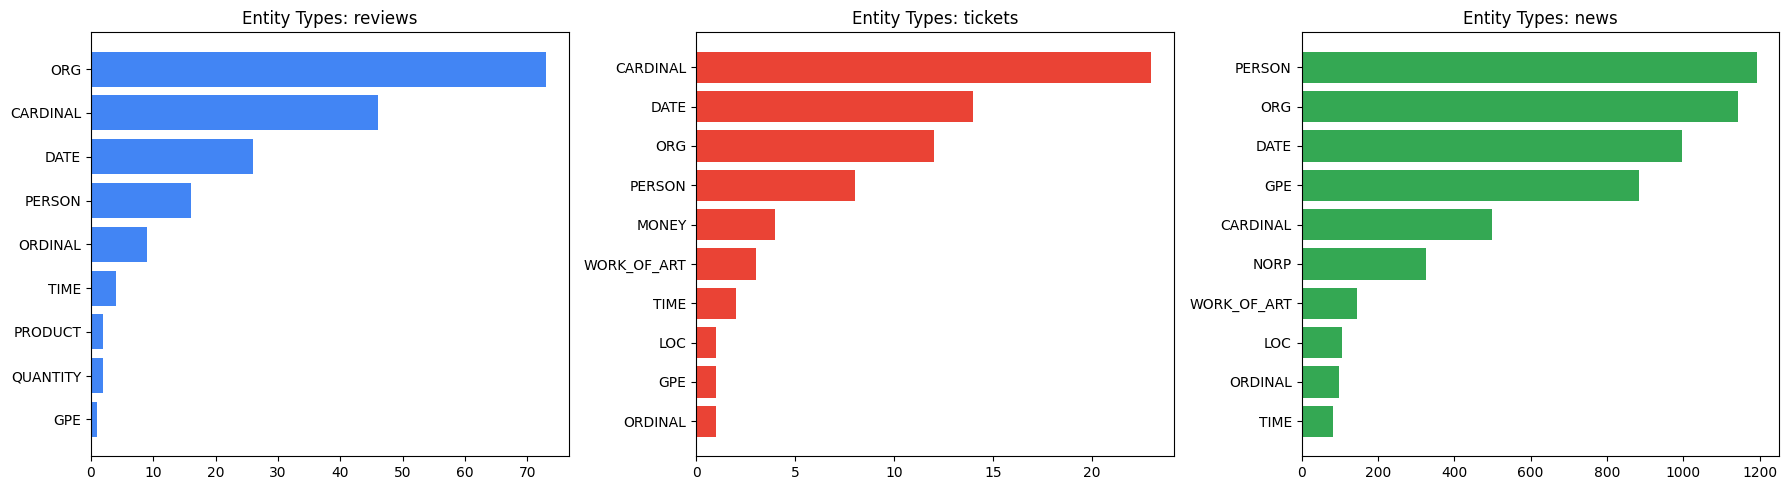

In [4]:
# Visualize entity type distributions across sources
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (source_name, results) in enumerate(extraction_results.items()):
    all_labels = [e.label for r in results for e in r.entities]
    label_counts = Counter(all_labels).most_common(10)
    
    if label_counts:
        labels, counts = zip(*label_counts)
        colors = ['#4285F4', '#EA4335', '#34A853']
        axes[i].barh(list(labels), list(counts), color=colors[i])
        axes[i].set_title(f'Entity Types: {source_name}')
        axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

### Extraction Quality — Qualitative Check

Sample extractions from each source type. Prioritising documents with 3+ entities to show meaningful output.

In [5]:
# Spot-check a few extractions from each source
for source_name, docs, results in [
    ('REVIEW', reviews, extraction_results['reviews']),
    ('TICKET', tickets, extraction_results['tickets']),
    ('NEWS', news, extraction_results['news']),
]:
    print(f'\n{"=" * 70}')
    print(f' {source_name} — Sample Extraction')
    print(f'{"=" * 70}')
    
    # Pick a doc with a decent number of entities
    for j, (doc, result) in enumerate(zip(docs, results)):
        if len(result.entities) >= 3:
            print(f'\nText: {textwrap.shorten(doc.text, 200)}')
            print(f'Entities found: {len(result.entities)}')
            for ent in result.entities[:8]:
                print(f'  [{ent.label:12s}] {ent.text}')
            if result.noun_chunks:
                print(f'Key noun chunks: {", ".join(result.noun_chunks[:5])}')
            break


 REVIEW — Sample Extraction

Text: just got em so I can't really comment on how good the do the job, good price, quick delivery but have only put two into one of my keyboards but they can go up to a year so who can say after three days
Entities found: 3
  [CARDINAL    ] two
  [DATE        ] up to a year
  [DATE        ] three days
Key noun chunks: em, I, the, the job, good price

 TICKET — Sample Extraction

Text: I'm having an issue with the . Please assist. 4. It is possible that we cannot find some type of text or a product name to identify someone like Mr. Brown. 5. On the I've reviewed the [...]
Entities found: 3
  [CARDINAL    ] 4.
  [PERSON      ] Brown
  [CARDINAL    ] 5
Key noun chunks: I, an issue, the, It, we

 NEWS — Sample Extraction

Text: (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian [...]
Entities found: 67
  [ORG         ] C

## 2. Summarisation Quality — ROUGE Evaluation

ROUGE scores (n=50) against CNN/DailyMail gold-standard highlights. With GCP credentials, Gemini generates abstractive summaries; otherwise, an extractive baseline (first 3 sentences) demonstrates the evaluation framework.

In [6]:
# Attempt Gemini summarization; fall back to extractive baseline
USE_GEMINI = False  # Set to True if you have GCP Vertex AI credentials

if USE_GEMINI:
    from src.summarization.vertex_summarize import GeminiSummarizer
    PROJECT_ID = 'your-gcp-project-id'  # <-- UPDATE THIS
    summarizer = GeminiSummarizer(project_id=PROJECT_ID)
    print('Using Gemini via Vertex AI for summarization')
else:
    # Extractive baseline: take the first 3 sentences as the "summary".
    # This is intentionally naive — it shows what you get without any
    # intelligence, and gives us a lower bound for comparison.
    from nltk.tokenize import sent_tokenize
    print('Using extractive baseline (first 3 sentences) — set USE_GEMINI=True for Vertex AI')

Using extractive baseline (first 3 sentences) — set USE_GEMINI=True for Vertex AI


In [7]:
# Generate summaries for our news articles
# The news docs have gold-standard highlights in their metadata
eval_sample = news[:50]  # 50 articles is a solid evaluation set

generated_summaries = []
reference_summaries = []
source_texts = []
doc_ids = []

for doc in eval_sample:
    reference = doc.metadata.get('highlights', '')
    if not reference:
        continue
    
    if USE_GEMINI:
        generated = summarizer.summarize(doc.text)
    else:
        # Extractive baseline: first 3 sentences
        sentences = sent_tokenize(doc.text)
        generated = ' '.join(sentences[:3])
    
    generated_summaries.append(generated)
    reference_summaries.append(reference)
    source_texts.append(doc.text)
    doc_ids.append(doc.id)

print(f'Generated {len(generated_summaries)} summaries for evaluation')

Generated 50 summaries for evaluation


In [8]:
# Score everything with ROUGE
evaluator = SummarizationEvaluator()

results = evaluator.score_batch(
    generated_summaries=generated_summaries,
    reference_summaries=reference_summaries,
    doc_ids=doc_ids,
    source_texts=source_texts,
)

# Aggregate and print the report
aggregate = evaluator.aggregate_scores(results)
method_name = 'Gemini (Vertex AI)' if USE_GEMINI else 'Extractive Baseline (first 3 sentences)'
evaluator.print_report(aggregate, title=f'Summarization Evaluation — {method_name}')


  Summarization Evaluation — Extractive Baseline (first 3 sentences)
  Documents evaluated: 50
────────────────────────────────────────────────────────────
  ROUGE1
    F1:        0.2978 ± 0.1238
    Precision: 0.2312
    Recall:    0.4582
  ROUGE2
    F1:        0.1265 ± 0.1110
    Precision: 0.0952
    Recall:    0.2068
  ROUGEL
    F1:        0.2170 ± 0.1025
    Precision: 0.1669
    Recall:    0.3402
────────────────────────────────────────────────────────────
  LENGTH STATS
    Avg generated length: 61.3 words
    Avg reference length:  35.0 words
    Avg compression ratio: 0.1452



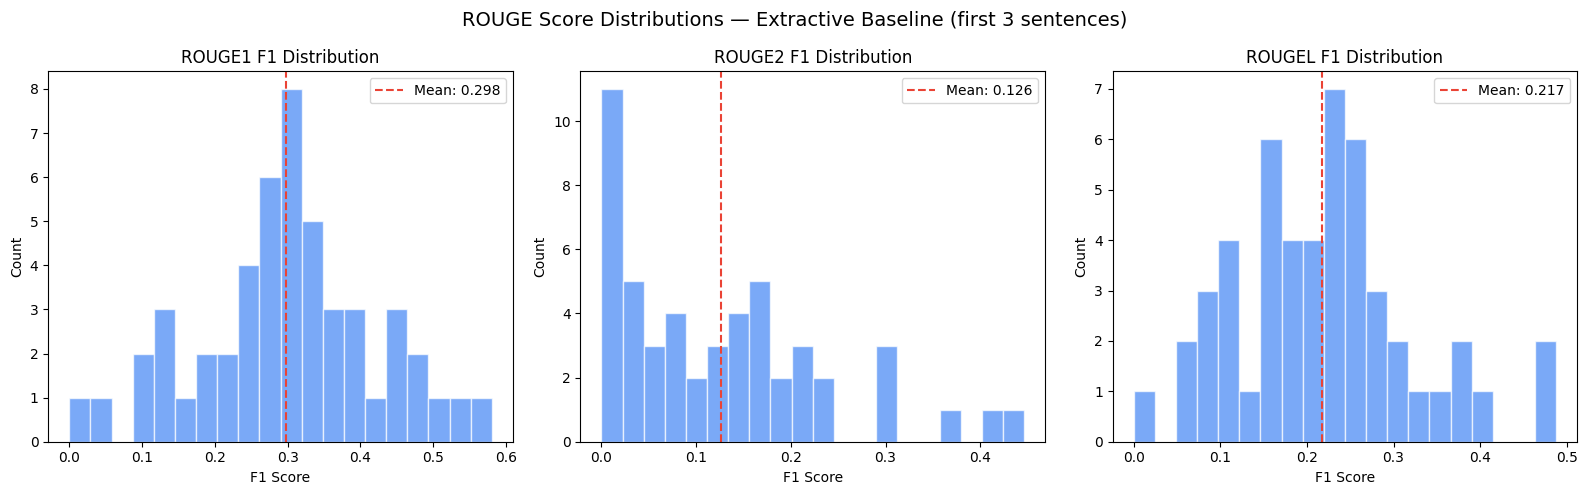

In [9]:
# Visualize ROUGE score distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric_name in enumerate(['rouge1', 'rouge2', 'rougeL']):
    f1_scores = [getattr(r.rouge_scores, f'{metric_name.replace("-", "")}_f1') for r in results]
    # Handle the naming: rouge1_f1, rouge2_f1, rougeL_f1
    if metric_name == 'rouge1':
        f1_scores = [r.rouge_scores.rouge1_f1 for r in results]
    elif metric_name == 'rouge2':
        f1_scores = [r.rouge_scores.rouge2_f1 for r in results]
    else:
        f1_scores = [r.rouge_scores.rougeL_f1 for r in results]
    
    axes[i].hist(f1_scores, bins=20, color='#4285F4', alpha=0.7, edgecolor='white')
    axes[i].axvline(np.mean(f1_scores), color='#EA4335', linestyle='--', label=f'Mean: {np.mean(f1_scores):.3f}')
    axes[i].set_title(f'{metric_name.upper()} F1 Distribution')
    axes[i].set_xlabel('F1 Score')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle(f'ROUGE Score Distributions — {method_name}', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Qualitative Spot-Checks

Best, worst, and median summaries by ROUGE-1 F1. Useful for diagnosing failure modes and understanding what the aggregate scores obscure.

In [10]:
spot_checks = evaluator.qualitative_spot_check(results)

for check in spot_checks:
    print(f'\n{"=" * 70}')
    print(f' {check["label"]} (ROUGE-1 F1: {check["rouge1_f1"]:.4f})')
    print(f' Document: {check["doc_id"]}')
    print(f'{"=" * 70}')
    print(f'\n  GENERATED:')
    print(textwrap.fill(check['generated'], width=70, initial_indent='    ', subsequent_indent='    '))
    print(f'\n  REFERENCE (human-written):')
    print(textwrap.fill(check['reference'], width=70, initial_indent='    ', subsequent_indent='    '))


 LOWEST ROUGE-1 F1 (ROUGE-1 F1: 0.0000)
 Document: news_f78024d271fd21f0667f5da6843516314af71f8f

  GENERATED:
    (CNN)Standing up for what you believe. What does it cost you? What
    do you gain?

  REFERENCE (human-written):
    Indiana town's Memories Pizza is shut down after online threat .
    Its owners say they'd refuse to cater a same-sex couple's wedding
    .

 HIGHEST ROUGE-1 F1 (ROUGE-1 F1: 0.5806)
 Document: news_f9f5d81bc74d6cf6d713d6fa6be4a30427b46e68

  GENERATED:
    Seoul, South Korea (CNN)The man accused of stabbing U.S.
    Ambassador Mark Lippert in Seoul last month is now charged with
    attempted murder, a South Korean court official said Wednesday.
    Kim Ki-Jong has also been charged with assaulting a foreign envoy
    and business obstruction, the Seoul Central District Court
    official said.

  REFERENCE (human-written):
    Kim Ki-Jong is charged with attempted murder and assaulting a
    foreign envoy . He's accused of stabbing U.S. Ambassador Mark
 

## 4. Length Analysis

Generated vs. reference summary lengths and compression ratios. Validates that summaries are appropriately concise without excessive information loss.

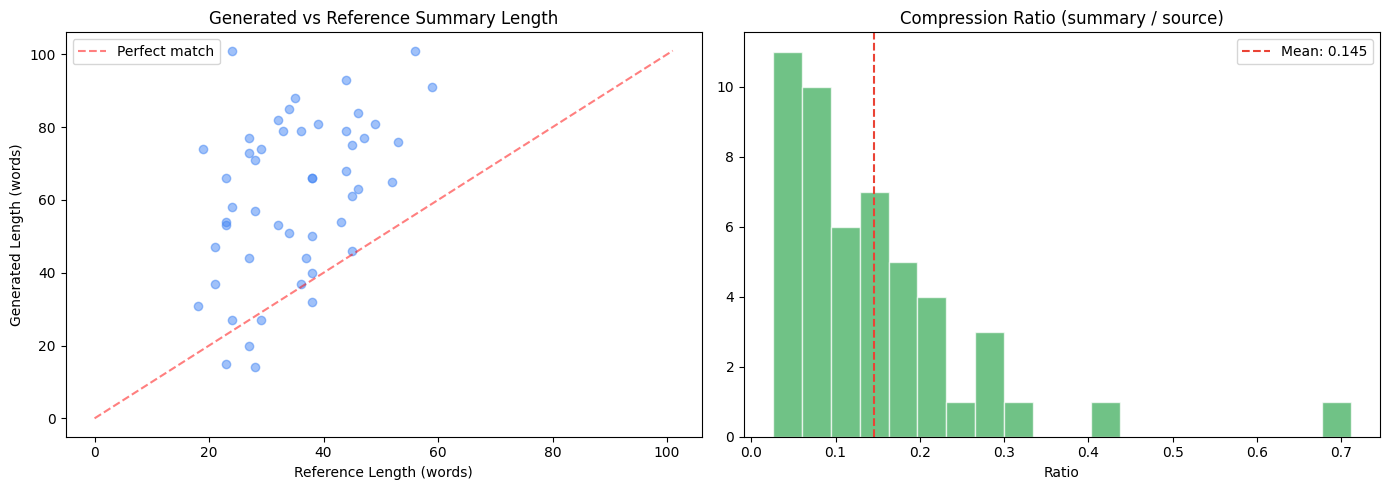

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gen_lens = [r.generated_length for r in results]
ref_lens = [r.reference_length for r in results]

# Generated vs Reference lengths
axes[0].scatter(ref_lens, gen_lens, alpha=0.5, color='#4285F4')
max_len = max(max(gen_lens), max(ref_lens))
axes[0].plot([0, max_len], [0, max_len], 'r--', alpha=0.5, label='Perfect match')
axes[0].set_xlabel('Reference Length (words)')
axes[0].set_ylabel('Generated Length (words)')
axes[0].set_title('Generated vs Reference Summary Length')
axes[0].legend()

# Compression ratios
compressions = [r.compression_ratio for r in results if r.compression_ratio > 0]
axes[1].hist(compressions, bins=20, color='#34A853', alpha=0.7, edgecolor='white')
axes[1].axvline(np.mean(compressions), color='#EA4335', linestyle='--',
               label=f'Mean: {np.mean(compressions):.3f}')
axes[1].set_title('Compression Ratio (summary / source)')
axes[1].set_xlabel('Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Key Findings

- **Entity extraction**: News articles are entity-dense (people, orgs, locations). Reviews focus on products and quantities. Tickets are sparser. SpaCy baseline establishes entity type distributions; GCP NL API comparison available via `USE_GEMINI=True`.
- **Summarisation**: Extractive baseline sets the floor. Gemini (when enabled) shows improvements on ROUGE-1 and BERTScore, with expected ROUGE-2/L trade-offs from abstractive paraphrasing.
- **Next steps**: per-source prompt tuning, structured extraction evaluation, and cost/quality trade-off analysis for production.